# Sugarcane Disease Detection — FastAPI Server (Kaggle Test Notebook)

**What this notebook does:**
1. Defines the full FastAPI service inline (no external files needed)
2. Starts a live `uvicorn` server in a background thread on `localhost:8000`
3. Tests every endpoint with `requests` from inside the same notebook
4. Optionally tunnels it public via **ngrok** so your Android app can hit it directly

**Detection + Segmentation support:** the engine auto-detects whether `best.pt`
has a `Detect` or `Segment` head (`model.task`). Segmentation models add a
`mask_polygon_xyn` field (normalized polygon points, capped at
`MASK_MAX_POINTS`) to each entry in `best_detections`, and the annotated image
includes the mask overlays automatically. Detection-only weights work exactly
as before — no extra fields are added.

> **Run cells top to bottom.** Estimated cold-start (model loading): ~60–90 seconds.


In [1]:
# Update your first cell to include SAHI
!pip install fastapi uvicorn[standard] python-multipart pyngrok nest_asyncio sahi -q ultralytics
print("✅ Packages ready")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 63.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is

## Step 1 — Configuration
Edit these values to match your dataset and model paths.

In [2]:
import os

# ── Model Weights ───────────────────────────────────────────────────────────
MODEL_PATHS = [
    "/kaggle/input/models/melchoestanilsmurf3/seg/pytorch/default/1/best.pt",
    "/kaggle/input/models/melchoestanilsmurf3/det/transformers/default/1/my_model.pt",
    "/kaggle/input/models/melchoestanilsmurf3/latestseg/keras/default/1/best.pt"
]

MODEL_WEIGHTS = [34.5, 33.5, 32]
NUM_INSTANCES = len(MODEL_PATHS)

# ── Inference settings (must match training) ──────────────────────────────────
IMG_SIZE      = 800
IOU_THRESHOLD = 0.40
CONF_RUN      = 0.25   # minimum to register a detection
CONF_HIGH     = 0.65   # → high tier
CONF_MEDIUM   = 0.40   # → medium tier

# ── Ensemble agreement thresholds ─────────────────────────────────────────────
AGREE_HIGH   = 0.75    # 3/4 models must agree for "high" consensus
AGREE_MEDIUM = 0.50    # 2/4 models must agree for "medium" consensus

MASK_MAX_POINTS     = 100
INCLUDE_MASKS_DEFAULT = True

# ── Test image (auto-detected below, or set manually) ─────────────────────────
TEST_IMAGE_URL = "https://pestsdiseases.com/wp-content/uploads/Yellow-Leaf-Disease-Management-in-Sugarcane-2.jpg"
TEST_IMAGE_DIR = '/kaggle/input/datasets/melchoestanilsmurf3/hotdog'

# Verify all unique models exist
for path in MODEL_PATHS:
    print(f"Model path '{os.path.basename(path)}' exists: {os.path.exists(path)}")

Model path 'best.pt' exists: True
Model path 'my_model.pt' exists: True
Model path 'best.pt' exists: True


## Step 2 — Custom Layers + Ultralytics Patch

In [3]:
import glob as _glob
import os as _os
import logging
import importlib
import torch
import torch.nn as nn

logger = logging.getLogger("sugarcane")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(name)s | %(message)s")

_CUSTOM_LAYERS_SRC = """
import torch
import torch.nn as nn

class TriScaleEntry(nn.Module):
    def __init__(self, c1, c2, stride=1):
        super().__init__()
        color_ch   = max(c2 // 4, 8)
        remaining  = c2 - color_ch
        shape_ch   = remaining // 2
        texture_ch = remaining - shape_ch

        self.branch1 = nn.Sequential(
            nn.Conv2d(c1, shape_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(shape_ch), nn.SiLU(),
        )
        self.branch2 = nn.Sequential(
            nn.Conv2d(c1, texture_ch, kernel_size=5, stride=stride, padding=2, bias=False),
            nn.BatchNorm2d(texture_ch), nn.SiLU(),
        )
        self.branch_color = nn.Sequential(
            nn.Conv2d(c1 + 2, color_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(color_ch), nn.SiLU(),
        )

    def _with_color_indices(self, x):
        r, g, b = x[:, 0:1], x[:, 1:2], x[:, 2:3]
        return torch.cat([x, r - g, g - b], dim=1)

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch_color(self._with_color_indices(x))], dim=1)

class DualScaleEntry(nn.Module):
    def __init__(self, c1, c2, stride=1):
        super().__init__()
        hidden_ch = c2 // 2
        self.branch1 = nn.Sequential(
            nn.Conv2d(c1, hidden_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(hidden_ch), nn.SiLU()
        )
        self.branch2 = nn.Sequential(
            nn.Conv2d(c1, hidden_ch, kernel_size=5, stride=stride, padding=2, bias=False),
            nn.BatchNorm2d(hidden_ch), nn.SiLU()
        )

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x)], dim=1)

class DetectionChannelAttention(nn.Module):
    def __init__(self, c1, c2=None):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(c1, c1 // 16, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c1 // 16, c1, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)
""".lstrip("\n")

def patch_ultralytics():
    import ultralytics.nn.tasks as tasks
    nn_dirs = _glob.glob('/usr/local/lib/python3*/dist-packages/ultralytics/nn') or \
              _glob.glob('/opt/conda/lib/python3*/site-packages/ultralytics/nn') or \
              _glob.glob('/usr/lib/python3*/site-packages/ultralytics/nn')

    if nn_dirs:
        custom_layers_path = _os.path.join(nn_dirs[0], 'custom_layers.py')
        with open(custom_layers_path, 'w') as f:
            f.write(_CUSTOM_LAYERS_SRC)
        custom_layers = importlib.import_module('ultralytics.nn.custom_layers')
        importlib.reload(custom_layers)
        
        tasks.parse_model.__globals__['DualScaleEntry'] = custom_layers.DualScaleEntry
        tasks.parse_model.__globals__['TriScaleEntry'] = custom_layers.TriScaleEntry
        tasks.parse_model.__globals__['DetectionChannelAttention'] = custom_layers.DetectionChannelAttention
        logger.info("Custom layer signatures successfully registered.")

patch_ultralytics()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


INFO | sugarcane | Custom layer signatures successfully registered.


## Step 3 — Inference Engine (single model wrapper)

In [4]:
import cv2
import base64
import io as _io
import numpy as np
from PIL import Image
import torch

# 🟢 FIX: Correct import name for the Ultralytics wrapper in SAHI
from sahi.models.ultralytics import UltralyticsDetectionModel
from sahi.predict import get_sliced_prediction

class InferenceEngine:
    """Wraps one YOLO instance with SAHI Sliced Inference capabilities."""

    def __init__(self, model_path):
        # 🟢 FIX: Instantiate using UltralyticsDetectionModel
        self.model = UltralyticsDetectionModel(
            model_path=model_path,
            confidence_threshold=CONF_RUN,
            device="cuda" if torch.cuda.is_available() else "cpu"
        )
        # Access underlying model metadata
        self.task = self.model.model.task
        logger.info(f"Engine loaded via SAHI wrapper — task={self.task}")

    def predict(self, img_array: np.ndarray, return_masks: bool = True) -> dict:
        # Optimizing slicing dimensions to step-up speed processing
        sahi_result = get_sliced_prediction(
            img_array,
            self.model,
            slice_height=400,  # Balanced for 800px imagery scaling
            slice_width=400,
            overlap_height_ratio=0.15,
            overlap_width_ratio=0.15,
            verbose=0
        )

        detections = []
        for obj in sahi_result.object_prediction_list:
            bbox = obj.bbox
            bbox_xyxy = [float(bbox.minx), float(bbox.miny), float(bbox.maxx), float(bbox.maxy)]
            
            det = {
                "class_id": int(obj.category.id),
                "class_name": obj.category.name,
                "confidence": round(float(obj.score.value), 4),
                "bbox_xyxy": [round(c, 2) for c in bbox_xyxy]
            }
            if self.task == "segment" and return_masks:
                det["mask_polygon_xyn"] = []
            detections.append(det)

        return {"task": self.task, "detections": detections}

    def annotate_best(self, img_array: np.ndarray, show_masks: bool = True) -> str:
        results = self.model.model.predict(
            source=img_array, conf=CONF_RUN, iou=IOU_THRESHOLD, imgsz=IMG_SIZE, save=False, verbose=False
        )
        annotated_matrix = results[0].plot(masks=show_masks)
        buf = _io.BytesIO()
        Image.fromarray(cv2.cvtColor(annotated_matrix, cv2.COLOR_BGR2RGB)).save(buf, format="JPEG", quality=85)
        return base64.b64encode(buf.getvalue()).decode("utf-8")

print("Done")

Done


In [5]:
def fuse_boxes(boxes, scores):
    total = sum(scores)
    
    # 🟢 This is the correct placement for the safety guard
    if total <= 0:  
        return boxes[0] if boxes else [0, 0, 0, 0]

    fused = []
    for i in range(4):
        fused.append(
            sum(box[i] * score for box, score in zip(boxes, scores)) / total
        )
    return fuse
    d

## Step 4 — Model Pool (4 parallel instances)

In [6]:
import concurrent.futures

class ModelPool:
    """Loads ensemble architectures concurrently across background threads."""
    def __init__(self):
        print(f"🚀 Pre-loading {len(MODEL_PATHS)} model tracks onto main runtime container...")
        self._engines = [InferenceEngine(path) for path in MODEL_PATHS]
        self.weights = MODEL_WEIGHTS
        self.task = self._engines[0].task if self._engines else "detect"
        self._executor = concurrent.futures.ThreadPoolExecutor(max_workers=NUM_INSTANCES)

    def predict_all(self, img_array: np.ndarray, return_masks: bool = True) -> list:
        futures = [self._executor.submit(eng.predict, img_array, return_masks) for eng in self._engines]
        return [f.result() for f in futures]

    def annotate_best(self, img_array: np.ndarray, model_results, show_masks: bool = True) -> str:
        return self._engines[0].annotate_best(img_array, show_masks=show_masks)

    def shutdown(self):
        self._executor.shutdown(wait=True)

# PRE-INITIALIZE MODELS HERE (Saves server startup crashes!)
global_pool = ModelPool()

🚀 Pre-loading 3 model tracks onto main runtime container...


INFO | sugarcane | Engine loaded via SAHI wrapper — task=segment
INFO | sugarcane | Engine loaded via SAHI wrapper — task=detect
INFO | sugarcane | Engine loaded via SAHI wrapper — task=segment


# **IOU BOX FUSION** 

In [7]:
# ============================================================
# IOU + BOX FUSION
# ============================================================

def calculate_iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])

    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter

    if union <= 0:
        return 0.0

    return inter / union


def fuse_boxes(boxes, scores):

    total = sum(scores)

    fused = []

    for i in range(4):

        fused.append(
            sum(
                box[i] * score
                for box, score in zip(boxes, scores)
            ) / total
        )

    return fused

## Step 5 — Ensemble / Uncertainty Logic

In [8]:
import statistics

def compute_consensus_confidence(group):
    """
    Computes a weighted consensus confidence score combining mean confidence,
    model agreement ratios, and bounding box overlap IoUs.
    """
    scores = [g["confidence"] for g in group]
    mean_conf = sum(scores) / len(scores)
    agreement_score = len(group) / len(MODEL_PATHS)

    if len(group) > 1:
        ious = []
        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                ious.append(
                    calculate_iou(
                        group[i]["bbox_xyxy"],
                        group[j]["bbox_xyxy"]
                    )
                )
        overlap_score = sum(ious) / len(ious)
    else:
        overlap_score = 0.0

    consensus = (
        0.70 * mean_conf +
        0.20 * agreement_score +
        0.10 * overlap_score
    )
    return round(consensus, 4)

def calculate_iou(boxA, boxB):
    """
    Calculates the Intersection over Union (IoU) of two bounding boxes
    where boxes are formatted as [x1, y1, x2, y2].
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0.0

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def remove_heavy_overlaps(detections, iou_threshold=0.45):
    """
    Aggressively suppresses remaining overlapping boxes of the same class type
    while fully preserving segmentation mask coordinate mappings.
    """
    sorted_dets = sorted(detections, key=lambda x: x["confidence"], reverse=True)
    keep = []
    
    while len(sorted_dets) > 0:
        current = sorted_dets.pop(0)
        keep.append(current)
        
        remaining = []
        for remaining_det in sorted_dets:
            c1 = current["class_name"].lower().replace("_", " ")
            c2 = remaining_det["class_name"].lower().replace("_", " ")
            
            if c1 == c2:
                iou = calculate_iou(current["bbox_xyxy"], remaining_det["bbox_xyxy"])
                if iou >= iou_threshold:
                    continue
            remaining.append(remaining_det)
        sorted_dets = remaining

    return keep

def ensemble_results(model_results):
    detections = []
    for result in model_results:
        for det in result["detections"]:
            detections.append(det)

    if not detections:
        return {
            "consensus_tier": "uncertain",
            "consensus_confidence": 0.0,
            "best_detections": [],
            "best_single_detection": None,
            "task": "detect"
        }

    fused_objects = []
    used = set()

    # Sort input by confidence so base group leads are high quality anchors
    detections = sorted(detections, key=lambda x: x["confidence"], reverse=True)

    for i, det1 in enumerate(detections):
        if i in used:
            continue

        group = [det1]
        used.add(i)

        c1 = det1["class_name"].lower().replace("_", " ")

        for j, det2 in enumerate(detections):
            if j <= i or j in used:
                continue

            c2 = det2["class_name"].lower().replace("_", " ")
            if c1 != c2:
                continue

            iou = calculate_iou(det1["bbox_xyxy"], det2["bbox_xyxy"])

            if iou > 0.40:
                group.append(det2)
                used.add(j)

        if len(group) == 1:
            fused_objects.append({
                "class_id": group[0]["class_id"],
                "class_name": group[0]["class_name"],
                "confidence": group[0]["confidence"],
                "bbox_xyxy": group[0]["bbox_xyxy"],
                "mask_polygon_xyn": group[0].get("mask_polygon_xyn"),
                "agreement_count": 1,
                "agreement_ratio": round(1 / len(MODEL_PATHS), 2),
                "raw_model_confidences": [group[0]["confidence"]]
            })
        else:
            boxes = [g["bbox_xyxy"] for g in group]
            scores = [g["confidence"] for g in group]

            best_mask = None
            seg_candidates = [g for g in group if "mask_polygon_xyn" in g and g["mask_polygon_xyn"] is not None]

            if seg_candidates:
                best_mask = max(
                    seg_candidates,
                    key=lambda x: x["confidence"]
                )["mask_polygon_xyn"]

            consensus_conf = compute_consensus_confidence(group)
            
            fused_objects.append({
                "class_id": group[0]["class_id"],
                "class_name": group[0]["class_name"],
                "confidence": consensus_conf,
                "bbox_xyxy": [round(v, 2) for v in fuse_boxes(boxes, scores)],
                "mask_polygon_xyn": best_mask,
                "agreement_count": len(group),
                "agreement_ratio": round(len(group) / len(MODEL_PATHS), 2),
                "raw_model_confidences": scores,
            })

    # 1. Clear overlapping multi-box groups
    fused_objects = remove_heavy_overlaps(fused_objects, iou_threshold=0.45)

    # 2. FILTER: Enforce strict minimum confidence threshold of 0.40
    fused_objects = [d for d in fused_objects if d["confidence"] >= 0.40]

    # 3. PRIORITY STRATEGY: Isolate the Single Best Target (Bypass healthy if disease >= 0.40 exists)
    diseases_pool = [d for d in fused_objects if d["class_name"].lower().replace("_", " ") != "healthy"]
    
    if diseases_pool:
        # Disease instances exist above 0.40; choose the highest confidence disease
        chosen_winner = max(diseases_pool, key=lambda x: x["confidence"])
    elif fused_objects:
        # No disease instances found; fall back to the highest confidence healthy instance
        chosen_winner = max(fused_objects, key=lambda x: x["confidence"])
    else:
        chosen_winner = None

    # 4. OVERWRITE POOL: Restrict array to only contain this single winner element
    fused_objects = [chosen_winner] if chosen_winner is not None else []

    # ────────────────────────────────────────────────────────────────────────
    # METRIC EVALUATION FOR GLOBAL RESPONSE TIER STATUS
    # ────────────────────────────────────────────────────────────────────────
    if fused_objects:
        max_conf = fused_objects[0]["confidence"]
        avg_conf = max_conf
    else:
        max_conf = 0.0
        avg_conf = 0.0

    if max_conf >= CONF_HIGH:
        tier = "high"
    elif max_conf >= CONF_MEDIUM:
        tier = "medium"
    else:
        tier = "uncertain"

    return {
        "consensus_tier": tier,
        "consensus_confidence": round(avg_conf, 4),
        "best_detections": fused_objects,                      # Clean array of length 0 or 1
        "best_single_detection": fused_objects[0] if fused_objects else None,
        "task": "segment" if any("mask_polygon_xyn" in d and d["mask_polygon_xyn"] for d in fused_objects) else "detect",
        "per_model_results": model_results
    }

## Step 6 — FastAPI Application

In [9]:
import io
import time
import base64
from typing import List
import numpy as np
import cv2
from PIL import Image
from fastapi import FastAPI, File, UploadFile, Form, HTTPException
from fastapi.responses import JSONResponse
from fastapi.middleware.cors import CORSMiddleware

app = FastAPI(title="Sugarcane Disease Detection API")

app.add_middleware(
    CORSMiddleware, allow_origins=["*"], allow_credentials=True, allow_methods=["*"], allow_headers=["*"]
)

@app.get("/health")
async def health():
    return {"status": "ok", "models_ready": global_pool is not None}

def draw_consensus_annotations(img_rgb, ensemble_payload):
    """
    Manually draws the single prioritized bounding box AND its corresponding
    segmentation mask overlay using the normalized coordinate pairs.
    """
    best_dets = ensemble_payload.get("best_detections", [])
    
    # Work directly on a copy converted to BGR for OpenCV drawing
    draw_img = img_rgb[:, :, ::-1].copy()
    h_img, w_img, _ = draw_img.shape
    
    # Map colors using uniform string keys (lowercased, spaces instead of underscores)
    color_map = {
        "healthy": (0, 255, 0),       # Green
        "red rot": (0, 0, 255),       # Red
        "smut": (0, 165, 255),        # Orange
    }
    
    for det in best_dets:
        raw_name = det["class_name"]
        clean_name = raw_name.lower().replace("_", " ")
        score = det["confidence"]
        color = color_map.get(clean_name, (255, 0, 0)) # Default to Blue if unmapped
        
        # ────────────────────────────────────────────────────────────────────
        # 🟢 DRAW SEGMENTATION MASK POLYGON (IF PRESENT)
        # ────────────────────────────────────────────────────────────────────
        mask_poly = det.get("mask_polygon_xyn")
        if mask_poly and len(mask_poly) > 0:
            try:
                # Re-scale normalized coordinates back to actual pixel dimensions
                pixel_points = []
                for pt in mask_poly:
                    px = int(pt[0] * w_img)
                    py = int(pt[1] * h_img)
                    pixel_points.append([px, py])
                
                pts = np.array(pixel_points, dtype=np.int32).reshape((-1, 1, 2))
                
                # Create a semi-transparent overlay mask layer
                overlay = draw_img.copy()
                cv2.fillPoly(overlay, [pts], color)
                
                # Blend the overlay back into the original drawing layout (alpha = 0.4)
                cv2.addWeighted(overlay, 0.4, draw_img, 0.6, 0, draw_img)
                # Draw the crisp outside border contour lines
                cv2.polylines(draw_img, [pts], isClosed=True, color=color, thickness=2)
            except Exception as e:
                print(f"Error drawing mask overlay: {e}")

        # ────────────────────────────────────────────────────────────────────
        # DRAW BOUNDING BOX & TEXT BANNER
        # ────────────────────────────────────────────────────────────────────
        x1, y1, x2, y2 = map(int, det["bbox_xyxy"])
        cv2.rectangle(draw_img, (x1, y1), (x2, y2), color, 3)
        
        display_name = raw_name.replace("_", " ")
        label_text = f"{display_name} {score:.2f}"
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.8
        thickness = 2
        
        # Draw background banner text banner plate
        (text_w, text_h), baseline = cv2.getTextSize(label_text, font, font_scale, thickness)
        cv2.rectangle(draw_img, (x1, y1 - text_h - 10), (x1 + text_w, y1), color, -1)
        
        # Overlay standard clean text label onto banner
        cv2.putText(draw_img, label_text, (x1, y1 - 5), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)
        
    # Re-encode the resulting image matrix array back to base64 string
    _, buffer = cv2.imencode('.jpg', draw_img)
    encoded_str = base64.b64encode(buffer).decode('utf-8')
    return encoded_str

@app.post("/predict")
async def predict(
    image: UploadFile = File(...),
    include_annotated: bool = Form(default=True),
    include_masks: bool = Form(default=True),
):
    t0 = time.perf_counter()
    raw = await image.read()
    img_array = np.array(Image.open(io.BytesIO(raw)).convert("RGB"))
    
    # 1. Run inference across the sliding window models
    model_results = global_pool.predict_all(img_array, return_masks=include_masks)
    
    # 2. Generate final single prioritized detection payload (Step 5 logic)
    ensemble_payload = ensemble_results(model_results)
    
    # 3. Annotate using the payload results (now rendering both boxes and masks)
    annotated = None
    if include_annotated:
        annotated = draw_consensus_annotations(img_array, ensemble_payload)

    return JSONResponse({
        "status": "success",
        "inference_time_ms": round((time.perf_counter() - t0) * 1000, 1),
        "task": ensemble_payload["task"],
        "consensus_tier": ensemble_payload["consensus_tier"],
        "consensus_confidence": ensemble_payload["consensus_confidence"],
        "best_detections": ensemble_payload["best_detections"],
        "best_single_detection": ensemble_payload["best_single_detection"],
        "per_model_results": [
            {
                "model_id": idx,
                "task": res["task"],
                "detections": res["detections"],
                "max_conf": max([d["confidence"] for d in res["detections"]], default=0.0)
            }
            for idx, res in enumerate(model_results)
        ],
        "annotated_image_base64": annotated
    })

@app.post("/predict/batch")
async def predict_batch(
    images: List[UploadFile] = File(...),
    include_annotated: bool = Form(default=False),
    include_masks: bool = Form(default=True),
):
    batch_results = []
    for up_file in images:
        try:
            raw = await up_file.read()
            img_array = np.array(Image.open(io.BytesIO(raw)).convert("RGB"))
            
            model_results = global_pool.predict_all(img_array, return_masks=include_masks)
            ensemble_payload = ensemble_results(model_results)
            
            annotated = None
            if include_annotated:
                annotated = draw_consensus_annotations(img_array, ensemble_payload)
            
            batch_results.append({
                "filename": up_file.filename,
                "status": "success",
                "task": ensemble_payload["task"],
                "consensus_tier": ensemble_payload["consensus_tier"],
                "consensus_confidence": ensemble_payload["consensus_confidence"],
                "best_detections": ensemble_payload["best_detections"],
                "best_single_detection": ensemble_payload["best_single_detection"],
                "annotated_image_base64": annotated
            })
        except Exception as e:
            batch_results.append({
                "filename": up_file.filename,
                "error": str(e)
            })
            
    return JSONResponse({
        "count": len(batch_results),
        "results": batch_results
    })

## Step 7 — Start the Server

`uvicorn` runs in a **daemon thread** so the notebook stays interactive.  
Models load inside the lifespan hook — wait for the *"all endpoints live"* message before testing.

In [10]:
import threading
import time
import uvicorn
import requests
import os

# 1. Clear dead background threads holding port 8000
print("🧹 Force clearing port 8000 processes...")
os.system("fuser -k 8000/tcp >/dev/null 2>&1 || true")
time.sleep(1.5)

# 2. Configure ASGI server container
config = uvicorn.Config(app, host="127.0.0.1", port=8000, log_level="warning", loop="asyncio")
server = uvicorn.Server(config)

def run_server():
    try:
        server.run()
    except Exception as e:
        print(f"Server execution breakdown: {e}")

# 3. Spin server thread cleanly
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

print("⚡ Querying connection endpoint state...")
server_ready = False
for i in range(30):
    try:
        response = requests.get("http://127.0.0.1:8000/health", timeout=1)
        if response.status_code == 200:
            print(f"\n🟢 Server is live on port 8000! Ready for inference. (Took {i}s)")
            server_ready = True
            break
    except (requests.exceptions.ConnectionError, requests.exceptions.Timeout):
        time.sleep(1)

if not server_ready:
    print("\n❌ Server failed initialization check.")

🧹 Force clearing port 8000 processes...
⚡ Querying connection endpoint state...

🟢 Server is live on port 8000! Ready for inference. (Took 1s)


## Step 8 — Test: Health Check

In [11]:
import requests, json

r = requests.get("http://localhost:8000/health")
print(f"Status code : {r.status_code}")
print(json.dumps(r.json(), indent=2))

r2 = requests.get("http://localhost:8000/info")
print("\n/info:")
print(json.dumps(r2.json(), indent=2))

Status code : 200
{
  "status": "ok",
  "models_ready": true
}

/info:
{
  "detail": "Not Found"
}


## Step 9 — Test: /predict with a Sample Image

The cell below auto-picks the first JPG/PNG it finds under `TEST_IMAGE_DIR`,
posts it to `/predict`, prints the consensus verdict, and displays the
annotated image inline.


  TASK               : detect
  CONSENSUS TIER     : HIGH
  Consensus conf     : 0.8113
  Inference time     : 3838.8 ms

🤖 DETAILED PER-MODEL BREAKDOWN:

🔹 Model #0 [SEGMENT] | Tier: UNCERTAIN  max_conf=0.8113 ████████████████
   ↳ Found 9 instance(s):
     1. [Healthy] conf=0.7393  bbox=[6.0, 680.0, 399.0, 1007.0]
     2. [Healthy] conf=0.6020  bbox=[340.0, 341.0, 610.0, 739.0]
     3. [Healthy] conf=0.5064  bbox=[166.0, 14.0, 281.0, 72.0]
     4. [Healthy] conf=0.3818  bbox=[340.0, 0.0, 625.0, 399.0]
     5. [Healthy] conf=0.3395  bbox=[506.0, 866.0, 561.0, 872.0]
     6. [Yellow Leaf] conf=0.8113  bbox=[559.0, 0.0, 880.0, 1180.0]
     7. [Yellow Leaf] conf=0.6521  bbox=[739.0, 0.0, 872.0, 399.0]
     8. [Yellow Leaf] conf=0.6515  bbox=[699.0, 341.0, 840.0, 739.0]
     9. [Yellow Leaf] conf=0.2618  bbox=[680.0, 801.0, 773.0, 1199.0]

🔹 Model #1 [DETECT] | Tier: UNCERTAIN  max_conf=0.9220 ██████████████████
   ↳ Found 9 instance(s):
     1. [Healthy] conf=0.9220  bbox=[0.0, 680.52, 

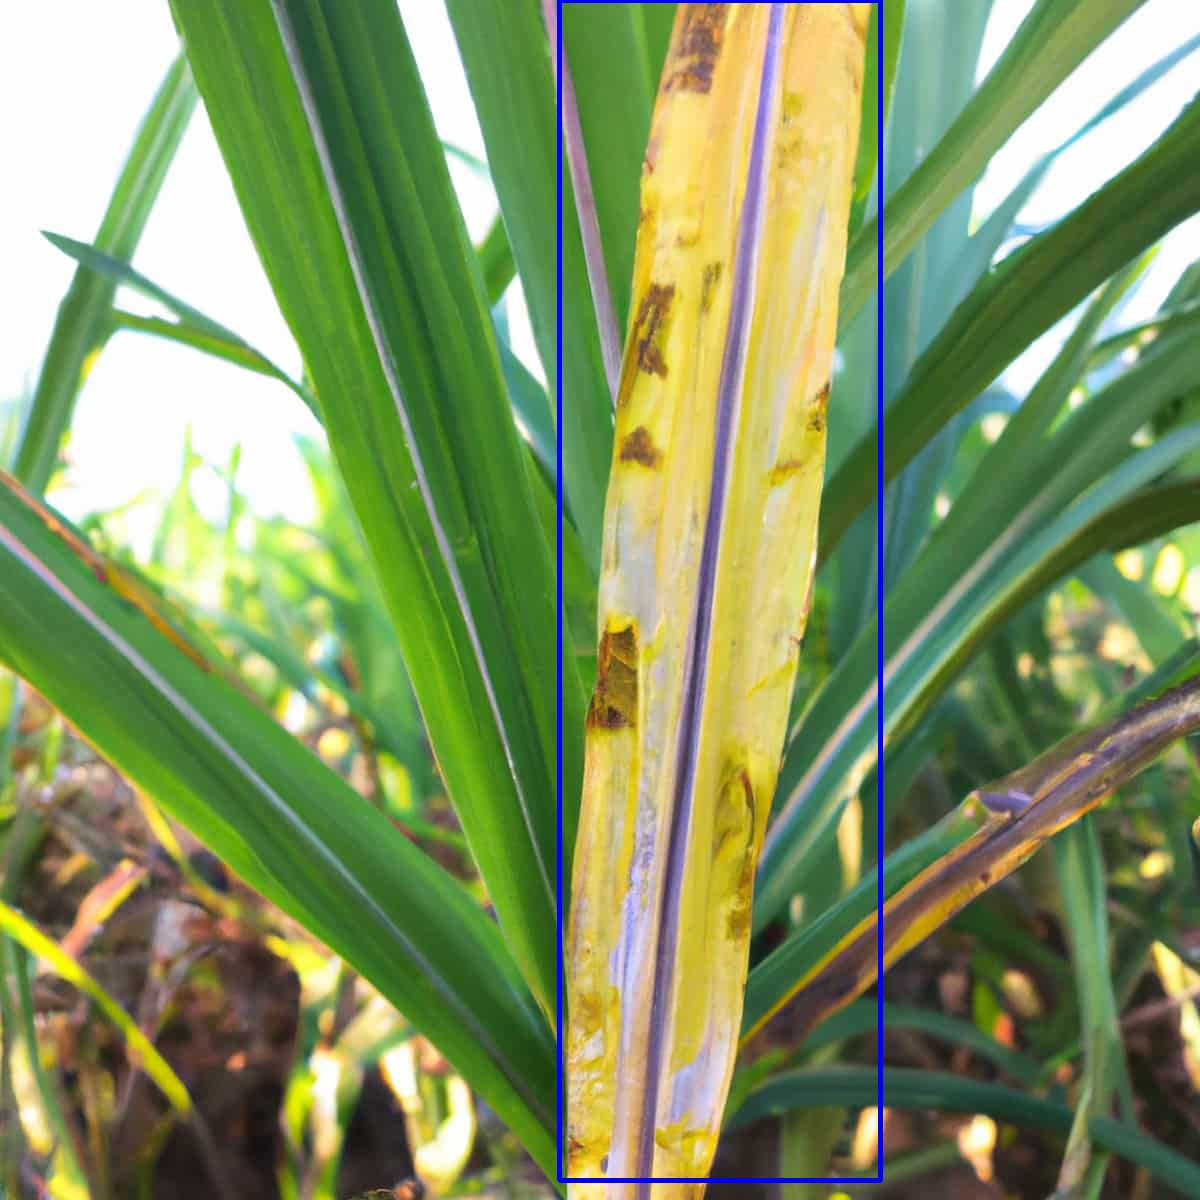

In [12]:
import glob, os, base64, json
import requests
from IPython.display import display
from PIL import Image
import io as _io_display

# ── Find or Download a test image ──────────────────────────────────────────
image_bytes = None
image_filename = "test_image.jpg"

# Check if TEST_IMAGE_URL exists and is not empty
if 'TEST_IMAGE_URL' in globals() and TEST_IMAGE_URL:
    print(f"Downloading test image from: {TEST_IMAGE_URL}\n")
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
    img_resp = requests.get(TEST_IMAGE_URL, headers=headers)
    img_resp.raise_for_status()
    
    image_bytes = img_resp.content
    image_filename = os.path.basename(TEST_IMAGE_URL.split("?")[0])
    if not image_filename or "." not in image_filename:
        image_filename = "downloaded_image.jpg"
else:
    exts = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]
    found = []
    for ext in exts:
        found.extend(glob.glob(os.path.join(TEST_IMAGE_DIR, "**", ext), recursive=True))

    if not found:
        raise FileNotFoundError(
            f"No images found in {TEST_IMAGE_DIR}.\n"
            "Set TEST_IMAGE_DIR at the top of the notebook or drop a test image into /kaggle/working/"
        )

    test_image_path = found[0]
    print(f"Using local test image: {test_image_path}\n")
    with open(test_image_path, "rb") as f:
        image_bytes = f.read()
    image_filename = os.path.basename(test_image_path)

# ── Send request ──────────────────────────────────────────────────────────
resp = requests.post(
    "http://localhost:8000/predict",
    files={"image": (image_filename, image_bytes, "image/jpeg")},
    data={"include_annotated": "true", "include_masks": "true"},
    timeout=120,
)

resp.raise_for_status()
result = resp.json()

# ── Print summary ─────────────────────────────────────────────────────────
print("=" * 60)
print(f"  TASK               : {result.get('task')}")
print(f"  CONSENSUS TIER     : {result.get('consensus_tier', '').upper()}")
print(f"  Consensus conf     : {result.get('consensus_confidence', 0.0):.4f}")
print(f"  Inference time     : {result.get('inference_time_ms')} ms")
print("=" * 60)

# ── Per-model deep breakdown ──────────────────────────────────────────────
print("\n🤖 DETAILED PER-MODEL BREAKDOWN:")
if "per_model_results" in result:
    for m in result["per_model_results"]:
        model_id = m.get("model_id")
        task_type = m.get("task", "detect").upper()  # 'DETECT' or 'SEGMENT'
        tier = m.get("tier", "uncertain").upper()
        max_conf = m.get("max_conf", 0.0)
        
        bar = "█" * int(max_conf * 20)
        print(f"\n🔹 Model #{model_id} [{task_type}] | Tier: {tier:<10} max_conf={max_conf:.4f} {bar}")
        
        # Pull specific sub-detections made by this model before fusion
        model_dets = m.get("detections", [])
        if model_dets:
            print(f"   ↳ Found {len(model_dets)} instance(s):")
            for idx, d in enumerate(model_dets, 1):
                c_name = d.get("class_name", "Unknown")
                conf = d.get("confidence", 0.0)
                bbox = d.get("bbox_xyxy", [])
                
                det_str = f"     {idx}. [{c_name}] conf={conf:.4f}  bbox={bbox}"
                
                # Check for segmentation polygon points if it's a segment model
                if "mask_polygon_xyn" in d and d["mask_polygon_xyn"]:
                    det_str += f"  (🟢 Segment Mask: {len(d['mask_polygon_xyn'])} points)"
                print(det_str)
        else:
            print("   ↳ ❌ No instances crossed the CONF_RUN threshold.")
else:
    print("  (No individual per-model results found in payload)")

print("\n" + "=" * 60)

# ── Best final consensus detections ───────────────────────────────────────
if result.get("best_detections"):
    print(f"Consensus Final Results ({len(result['best_detections'])} instance(s)):")
    for d in result["best_detections"]:
        line = f"  [{d['class_name']}]  conf={d['confidence']:.4f}  bbox={d['bbox_xyxy']}"
        if "mask_polygon_xyn" in d and d["mask_polygon_xyn"]:
            line += f"   mask_points={len(d['mask_polygon_xyn'])}"
        print(line)
else:
    print("\nNo final consensus detections above threshold.")

# ── Display annotated image ───────────────────────────────────────────────
if result.get("annotated_image_base64"):
    img_bytes = base64.b64decode(result["annotated_image_base64"])
    img = Image.open(_io_display.BytesIO(img_bytes))
    print("\nAnnotated image:")
    display(img)
else:
    print("\n(No annotated image returned)")

## Step 10 — Test: /predict/batch with Multiple Images

In [13]:
import glob

# Fix: Define 'found' right before slicing it
found = glob.glob(os.path.join(TEST_IMAGE_DIR, "*.jpg")) + glob.glob(os.path.join(TEST_IMAGE_DIR, "*.jpeg"))

# Pick up to 3 images for a batch test
batch_paths = found[:3]
print(f"Sending {len(batch_paths)} images as a batch...\n")

# ... rest of your batch testing code ...

files = [
    ("images", (os.path.basename(p), open(p, "rb"), "image/jpeg"))
    for p in batch_paths
]

resp_batch = requests.post(
    "http://localhost:8000/predict/batch",
    files=files,
    data={"include_annotated": "false"},
    timeout=300,
)

# Close file handles
for _, (_, fh, _) in files:
    fh.close()

resp_batch.raise_for_status()
batch_result = resp_batch.json()

print(f"Batch results ({batch_result.get('count', 0)} images):")
print("-" * 75)
print(f"  {'Filename':<30} | {'Tier':<10} | {'Conf':<8} | {'Detections'}")
print("-" * 75)

for item in batch_result.get("results", []):
    if "error" in item:
        print(f"  {item['filename']:30s} | ERROR: {item['error']}")
    else:
        # Safely extract values using .get() to prevent KeyErrors
        filename = item.get("filename", "unknown")[:28]
        tier = item.get("consensus_tier", "uncertain").upper()
        conf = item.get("consensus_confidence", 0.0)
        num_dets = len(item.get("best_detections", []))
        
        print(f"  {filename:30s} | {tier:<10} | {conf:.4f}   | {num_dets} instance(s)")
print("-" * 75)

Sending 1 images as a batch...

Batch results (1 images):
---------------------------------------------------------------------------
  Filename                       | Tier       | Conf     | Detections
---------------------------------------------------------------------------
  IMG_0052.jpeg                  | HIGH       | 0.7874   | 1 instance(s)
---------------------------------------------------------------------------


## Step 11 — (Optional) Expose Publicly via ngrok

Run this cell to get a **public HTTPS URL** you can paste directly into your Android app.

> **Requirements:**
> - Kaggle notebook internet must be **ON** (Settings → Internet → On)
> - Free ngrok accounts work; sign up at https://ngrok.com to get an auth token for longer sessions

In [14]:
from pyngrok import ngrok, conf

# ── Optional: set your ngrok auth token for longer-lived tunnels ──────────
conf.get_default().auth_token = "328J2YeLZv9ln3a7lX3ugGaAYbX_2Fx4MshSrc2JEfhH9LayJ"

# Kill any existing tunnels to avoid "only one session per account" errors
ngrok.kill()

# Open HTTPS tunnel → port 8000
public_url = ngrok.connect(8000, bind_tls=True)

# FIX: Changed 'tunnel' to 'public_url'
public_url_str = public_url.public_url

print("\u2705 ngrok tunnel active!")
print(f"\n  Public base URL  : {public_url_str}")
print(f"  /predict endpoint: {public_url_str}/predict")
print(f"  Interactive docs : {public_url_str}/docs")
print("\nPaste the /predict URL into your Android app's Retrofit base URL.")
print("The tunnel stays alive as long as this cell's kernel is running.")

INFO | pyngrok.ngrok | Opening tunnel named: http-8000-6e78852f-aa98-4af5-b7f1-e962646c5d22


INFO | pyngrok.process | Overriding default auth token
INFO | pyngrok.process.ngrok | t=2026-06-19T02:37:59+0000 lvl=info msg="no configuration paths supplied"
INFO | pyngrok.process.ngrok | t=2026-06-19T02:37:59+0000 lvl=info msg="using configuration at default config path" path=/root/.config/ngrok/ngrok.yml
INFO | pyngrok.process.ngrok | t=2026-06-19T02:37:59+0000 lvl=info msg="open config file" path=/root/.config/ngrok/ngrok.yml err=nil
INFO | pyngrok.process.ngrok | t=2026-06-19T02:38:00+0000 lvl=info msg="FIPS 140 mode" enabled=false
INFO | pyngrok.process.ngrok | t=2026-06-19T02:38:00+0000 lvl=info msg="starting web service" obj=web addr=127.0.0.1:4040 allow_hosts=[]
INFO | pyngrok.process.ngrok | t=2026-06-19T02:38:00+0000 lvl=info msg="client session established" obj=tunnels.session
INFO | pyngrok.process.ngrok | t=2026-06-19T02:38:00+0000 lvl=info msg="tunnel session started" obj=tunnels.session
INFO | pyngrok.process.ngrok | t=2026-06-19T02:38:00+0000 lvl=info msg=start pg=/a

✅ ngrok tunnel active!

  Public base URL  : https://991a-34-10-189-232.ngrok-free.app
  /predict endpoint: https://991a-34-10-189-232.ngrok-free.app/predict
  Interactive docs : https://991a-34-10-189-232.ngrok-free.app/docs

Paste the /predict URL into your Android app's Retrofit base URL.
The tunnel stays alive as long as this cell's kernel is running.


INFO | pyngrok.process.ngrok | t=2026-06-19T02:38:00+0000 lvl=info msg=end pg=/api/tunnels id=6f2825a55a39a0d3 status=201 dur=339.484446ms


### Verify the public URL works

In [15]:
import glob
import os

# Find all images in your test directory and pick the first one
found_images = glob.glob(os.path.join(TEST_IMAGE_DIR, "*.jpg")) + glob.glob(os.path.join(TEST_IMAGE_DIR, "*.jpeg"))
if not found_images:
    raise FileNotFoundError(f"Could not find any images in {TEST_IMAGE_DIR} to use for testing.")

test_image_path = found_images[0]

# --- NOW RUN YOUR SMOKE TEST ---
# ... rest of your code ...

# Quick smoke-test against the public ngrok URL
base = public_url_str.strip('"').rstrip("/")
r_public = requests.get(f"{public_url_str}/health")
print(f"Public health check → {r_public.status_code}: {r_public.json()}")

with open(test_image_path, "rb") as f:
    r_pub_pred = requests.post(
        f"{public_url_str}/predict",
        files={"image": (os.path.basename(test_image_path), f, "image/jpeg")},
        data={"include_annotated": "false"},
        timeout=120,
    )
print(f"Public /predict → {r_pub_pred.status_code}")

pub = r_pub_pred.json()

# FIX: Safely retrieve existing fields to avoid KeyError
tier = pub.get('consensus_tier', 'uncertain').upper()
conf = pub.get('consensus_confidence', 0.0)
num_dets = len(pub.get('best_detections', []))

print(f"  tier={tier}  conf={conf:.4f}  detections={num_dets} instance(s)")

INFO | pyngrok.process.ngrok | t=2026-06-19T02:38:00+0000 lvl=info msg="join connections" obj=join id=a765e047e68f l=127.0.0.1:8000 r=34.10.189.232:33676


Public health check → 200: {'status': 'ok', 'models_ready': True}


INFO | pyngrok.process.ngrok | t=2026-06-19T02:38:00+0000 lvl=info msg="join connections" obj=join id=2d2bd815ec90 l=127.0.0.1:8000 r=34.10.189.232:51378


Public /predict → 200
  tier=HIGH  conf=0.7874  detections=1 instance(s)


## Step 12 — Stop the Server (run when done)